Using p range: [0.750000, 0.900000]  (N=16)


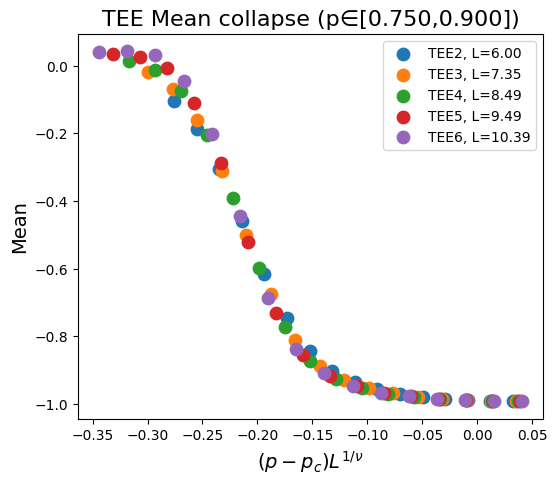

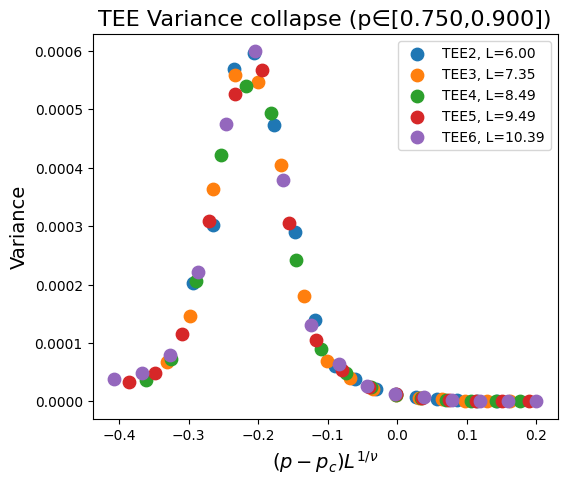

=== 平均 FSS ===
pc = 0.8841974733633415 ± 0.09107105517729028
nu = 2.485910941623879 ± 2.2903545662305933
zeta = 0.006881087931412516 ± 0.03902880281883837
S (mean) = 172.53799006848197

=== 分散 FSS ===
pc = 0.8506050999176 ± 0.0024927993470775785
nu = 1.6723817231076383 ± 0.09007189551855911
zeta = 2.5475499030379423 ± 1.0099676128189607
S (var)  = 0.0557138129422751


In [9]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.75, 0.90

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.8, nu0=1.6, zeta0=1.9)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.85, nu0=1.6, zeta0=2.0)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_pz0_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))


In [17]:
# -*- coding: utf-8 -*-
# Peak-shift fit (p_peak(L)=pc + a L^{-1/nu}) + Peak-height fit (Amax ~ L^{zeta/nu})
# 必要: numpy, matplotlib（任意）。SciPy不要。

import numpy as np

# === 入力設定（あなたのデータに合わせて） ===
npz_path = "Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz"
TEE_keys = ['TEE2','TEE3','TEE4','TEE5','TEE6']   # 使う系列（行）
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]

# どの量でピークを見るか（分散推奨）
TARGET = "var"   # "var" or "ave" など

# === データ読み込み ===
d = np.load(npz_path)
p = d["pg"].astype(float)                 # shape (nP,)
# 量の行列を組む: rows=nL, cols=nP
A = np.array([d[f"{k}_{TARGET}"] for k in TEE_keys], dtype=float)

# === 各Lでピーク位置/高さを推定（3点二次補間で精緻化）===
def quad_vertex(x, y):
    # 3点 (x0,y0),(x1,y1),(x2,y2) から頂点位置を返す。中心点が極大近傍である前提。
    x0,x1,x2 = x
    y0,y1,y2 = y
    denom = (x0-x1)*(x0-x2)*(x1-x2)
    if denom == 0: return x1, y1
    a = (x2*(y1-y0)+x1*(y0-y2)+x0*(y2-y1)) / denom
    b = (x2**2*(y0-y1)+x1**2*(y2-y0)+x0**2*(y1-y2)) / denom
    xv = -b/(2*a) if a != 0 else x1
    yv = a*xv*xv + b*xv + (y0 - a*x0*x0 - b*x0)
    return xv, yv

p_peaks = []
A_peaks = []
for i in range(A.shape[0]):
    yi = A[i]
    j = int(np.argmax(yi))
    # 端ならそのまま、内部なら3点で二次補間
    if 0 < j < len(p)-1:
        xv, yv = quad_vertex(p[j-1:j+2], yi[j-1:j+2])
        # 補間が範囲外に飛んだら元の最大を採用
        if (xv < p[j-1]) or (xv > p[j+1]):
            xv, yv = p[j], yi[j]
    else:
        xv, yv = p[j], yi[j]
    p_peaks.append(xv); A_peaks.append(abs(yv))  # 念のため絶対値

p_peaks = np.array(p_peaks)  # shape (nL,)
A_peaks = np.array(A_peaks)
L = np.array(L_list, float)

print("[peaks] L      p_peak       A_peak")
for Li, pp, ap in zip(L, p_peaks, A_peaks):
    print(f"         {Li:6.3f}  {pp:9.6f}   {ap:.6g}")

# === (1) p_peak(L) = pc + a * L^{-1/nu} で (pc,nu) を決める ===
# nu をグリッド走査し、X=L^{-1/nu} に対して p_peak ~ pc + a X を最小二乗
nu_grid = np.linspace(1.0, 3.0, 401)   # 必要なら範囲/刻みを調整
best = None  # (SSE, nu, pc, a)
for nu in nu_grid:
    X = L**(-1.0/nu)
    # 線形回帰: p_peak = pc + a*X
    Xmat = np.column_stack([np.ones_like(X), X])
    coef, *_ = np.linalg.lstsq(Xmat, p_peaks, rcond=None)
    pc, a = coef
    resid = p_peaks - (pc + a*X)
    sse = np.sum(resid**2)
    if (best is None) or (sse < best[0]):
        best = (sse, nu, pc, a)

sse, nu_hat, pc_hat, a_hat = best
print("\n=== Peak-shift fit ===")
print(f"pc ≈ {pc_hat:.6f}")
print(f"nu ≈ {nu_hat:.6f}  (from p_peak shift)")
print(f"SSE_shift = {sse:.3e}")

# 粗い誤差の当たりを出したければ、LのLOOジャックナイフ:
pcs, nus = [], []
for i_out in range(L.size):
    idx = np.arange(L.size) != i_out
    Li, ppi = L[idx], p_peaks[idx]
    best_i = None
    for nu in nu_grid:
        Xi = Li**(-1.0/nu)
        Xmat = np.column_stack([np.ones_like(Xi), Xi])
        coef, *_ = np.linalg.lstsq(Xmat, ppi, rcond=None)
        pc_i, a_i = coef
        sse_i = np.sum((ppi - (pc_i + a_i*Xi))**2)
        if (best_i is None) or (sse_i < best_i[0]):
            best_i = (sse_i, nu, pc_i)
    pcs.append(best_i[2]); nus.append(best_i[1])

def jackknife_se(vals):
    vals = np.asarray(vals, float)
    n = vals.size
    mean = vals.mean()
    se = np.sqrt((n-1)/n * np.sum((vals-mean)**2))
    return mean, se

pc_mean, pc_se = jackknife_se(pcs)
nu_mean, nu_se = jackknife_se(nus)
print("\n[JACKKNIFE over L]")
print(f"pc = {pc_mean:.6f} ± {pc_se:.6f}")
print(f"nu = {nu_mean:.6f} ± {nu_se:.6f}")

# === (2) ピーク高さ: A_peak(L) ~ L^{zeta/nu} → 傾き s = zeta/nu ===
# log-log で線形回帰
mask_pos = (A_peaks > 0)
logL = np.log(L[mask_pos]); logA = np.log(A_peaks[mask_pos])
M = np.column_stack([np.ones_like(logL), logL])
b, *_ = np.linalg.lstsq(M, logA, rcond=None)  # logA ≈ b0 + s logL
s = b[1]  # s = zeta/nu
zeta_hat = s * nu_hat

# LのLOOジャックナイフ（s と zeta）:
ss = []
for i_out in range(logL.size):
    idx = np.arange(logL.size) != i_out
    Mi = np.column_stack([np.ones_like(logL[idx]), logL[idx]])
    bi, *_ = np.linalg.lstsq(Mi, logA[idx], rcond=None)
    ss.append(bi[1])
s_mean, s_se = jackknife_se(ss)
zeta_mean = s_mean * nu_mean
# ざっくり誤差伝播（cov無視の近似）
zeta_se = np.sqrt( (nu_mean*s_se)**2 + (s_mean*nu_se)**2 )

print("\n=== Peak-height fit ===")
print(f"s = zeta/nu ≈ {s_mean:.6f} ± {s_se:.6f}")
print(f"zeta ≈ {zeta_mean:.6f} ± {zeta_se:.6f}  (using nu from shift)")


[peaks] L      p_peak       A_peak
          6.000   0.776870   0.00926218
          7.348   0.784361   0.0120792
          8.485   0.792179   0.0141036
          9.487   0.796346   0.0180784
         10.392   0.798616   0.02131

=== Peak-shift fit ===
pc ≈ 0.900156
nu ≈ 2.715000  (from p_peak shift)
SSE_shift = 2.634e-06

[JACKKNIFE over L]
pc = 0.879121 ± 0.078177
nu = 2.177000 ± 1.923867

=== Peak-height fit ===
s = zeta/nu ≈ 1.515491 ± 0.176117
zeta ≈ 3.299223 ± 2.940704  (using nu from shift)


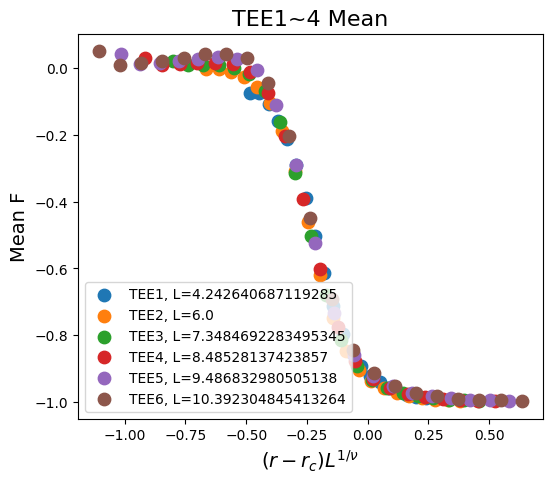

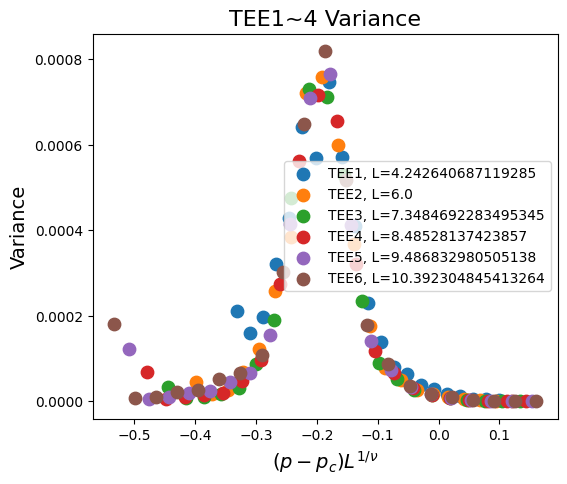

=== 分散 FSS ===
pc = 0.8537298292364497 ± nan
nu = 1.8794085736369328 ± nan
zeta = 2.6121650191999954 ± 0.28451288052460294
スケーリング品質 S = 0.1859556504541269


In [12]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
#markers = ['x', 'o', '^', 's']
#colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
#L_list = [12, 18, 24, 30]
#TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

L_list = [np.sqrt(18),np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE1','TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

# データ読み込み
data = np.load("Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal6.npz")
p_use = data['pg']

cmap = cm.get_cmap('gnuplot', 4)

# ----------------------
# 平均値 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=1.6, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean', fontsize=16)

# PNG保存
plt.savefig("TEE_pz_0.png", dpi=300, bbox_inches='tight')

# 図を表示（必要な場合）
plt.show()
plt.close(fig)  # メモリ解放
# ----------------------
# 分散 FSS
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 誤差の扱いは場合に応じて

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)

# PNG保存
plt.savefig("TEE_variance1-4.png", dpi=300, bbox_inches='tight')

# 図を表示
plt.show()
plt.close(fig)

print("=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("スケーリング品質 S =", fssa.quality(xs_var, ys_var, dys_var))




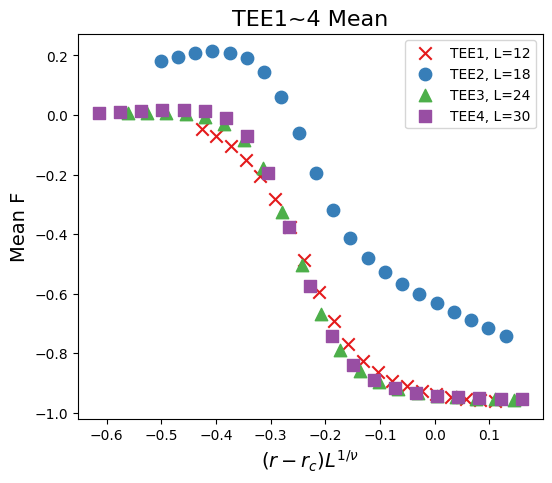

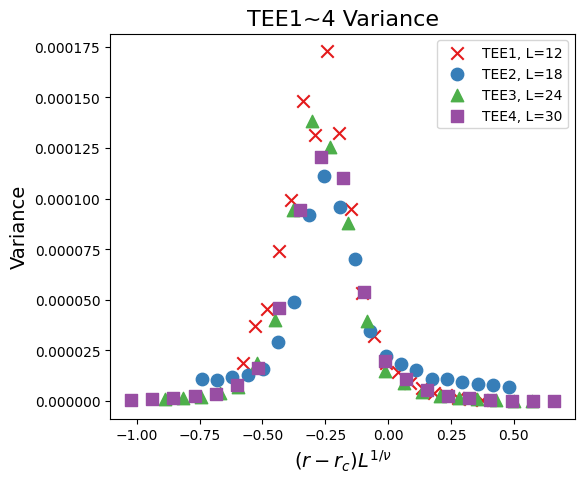

=== 分散 FSS ===
pc = 0.8215858551291775 ± 0.09278000547949403
nu = 1.5972425828482233 ± 2.558341019444451
zeta = 2.2328585990539347 ± 4.132490244800464
スケーリング品質 S = 0.2717455322219248


In [3]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
#L_list = [12, 18, 24, 30]
#TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

L_list = [12, 18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

cmap = cm.get_cmap('gnuplot', 4)

# ----------------------
# 平均値 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=1.6, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean', fontsize=16)

# PNG保存
plt.savefig("TEE_mean1-4.png", dpi=300, bbox_inches='tight')

# 図を表示（必要な場合）
plt.show()
plt.close(fig)  # メモリ解放
# ----------------------
# 分散 FSS
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 誤差の扱いは場合に応じて

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)

# PNG保存
plt.savefig("TEE_variance1-4.png", dpi=300, bbox_inches='tight')

# 図を表示
plt.show()
plt.close(fig)

print("=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("スケーリング品質 S =", fssa.quality(xs_var, ys_var, dys_var))




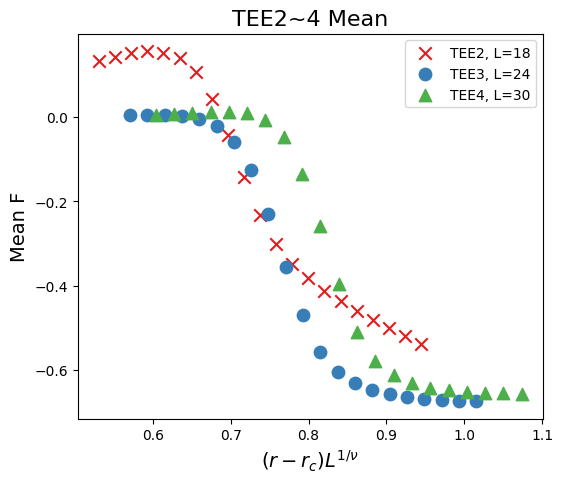

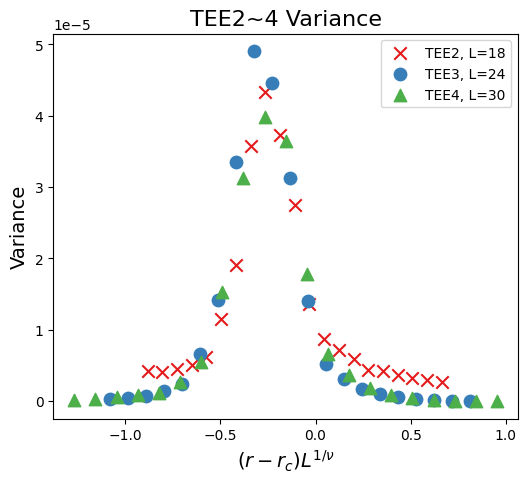

=== 分散 FSS ===
pc = 0.814126646457348 ± 0.01851380107587439
nu = 1.4121782278741875 ± 0.502822204102782
zeta = 2.433956437502757 ± 0.4420542843163297
スケーリング品質 S = 0.23095485237959693


In [11]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
#L_list = [12, 18, 24, 30]
#TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

L_list = [18, 24, 30]
TEE_keys = ['TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_24_Nd_500_NT_17280_pz_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

p_all = np.array(data['pg'], dtype=float)


pmin, pmax = 0.75, 0.9   
mask = (p_all >= pmin) & (p_all <= pmax)


cmap = cm.get_cmap('gnuplot', 4)

# ----------------------
# 平均値 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+2}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE2~4 Mean', fontsize=16)

# PNG保存
plt.savefig("TEE_mean2-4.png", dpi=300, bbox_inches='tight')

# 図を表示（必要な場合）
plt.show()
plt.close(fig)  # メモリ解放
# ----------------------
# 分散 FSS
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 誤差の扱いは場合に応じて

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.87, nu0=1.8, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+2}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE2~4 Variance', fontsize=16)

# PNG保存
plt.savefig("TEE_variance2-4.png", dpi=300, bbox_inches='tight')

# 図を表示
plt.show()
plt.close(fig)

print("=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("スケーリング品質 S =", fssa.quality(xs_var, ys_var, dys_var))




In [8]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors  = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# -------- ユーザー設定：ここを変えるだけ --------
L_list   = [18, 24, 30]
TEE_keys = ['TEE2', 'TEE3', 'TEE4']

use_value_range = True     # True: 値で範囲指定 / False: 端落とし
pmin, pmax = 0.70, 0.92    # 値での範囲指定（use_value_range=True のとき有効）
d = 0                      # 端落としの個数（use_value_range=False のとき有効）
# ---------------------------------------------

# データ読み込み
data   = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz")
p_full = np.array(data['pg'], dtype=float)  # shape: (Np,)

cmap = cm.get_cmap('gnuplot', 4)

# ------------- FSS 用データ構築（フル）-------------
a_mean_full = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)   # shape: (3, Np)
da_mean_full= np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var_full  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var_full = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 必要なら別誤差に

# ------------- p の取り直し（値 or 端落とし）-------------
if use_value_range:
    mask = (p_full >= 0.75) & (p_full <= pmax)
    if mask.sum() < 3:
        raise RuntimeError(f"選んだ p 範囲が狭すぎます: count={mask.sum()} (pmin={pmin}, pmax={pmax})")
    p_use   = p_full[mask]
    a_mean  = a_mean_full[:, mask]
    da_mean = da_mean_full[:, mask]
    a_var   = a_var_full[:, mask]
    da_var  = da_var_full[:, mask]
else:
    if 2*d >= len(p_full):
        raise RuntimeError(f"d={d} が大きすぎます（データ点 {len(p_full)} に対して）")
    sl      = slice(d, len(p_full)-d)
    p_use   = p_full[sl]
    a_mean  = a_mean_full[:, sl]
    da_mean = da_mean_full[:, sl]
    a_var   = a_var_full[:, sl]
    da_var  = da_var_full[:, sl]

# ---------------------- 平均 FSS ----------------------
ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.80, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               marker=markers[i], color=colors[i], s=80,
               label=f'L={L} ({TEE_keys[i]})')
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE2–4 Mean', fontsize=16)
plt.savefig("TEE_mean2-4.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print("=== 平均 FSS ===")
print("pc =", ret_mean.rho,  "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta,"±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

# ---------------------- 分散 FSS ----------------------
ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.87, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               marker=markers[i], color=colors[i], s=80,
               label=f'L={L} ({TEE_keys[i]})')
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE2–4 Variance', fontsize=16)
plt.savefig("TEE_variance2-4.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho,  "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta,"±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


FileNotFoundError: [Errno 2] No such file or directory: 'Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz'

In [2]:
import numpy as np

data = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz")
print(data.files)

['pg', 'TEE1_ave', 'TEE1_err', 'TEE1_var', 'TEE2_ave', 'TEE2_err', 'TEE2_var', 'TEE3_ave', 'TEE3_err', 'TEE3_var', 'TEE4_ave', 'TEE4_err', 'TEE4_var']


=== TEE1 mean, L=12 ===


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:441: RuntimeWarning: Mean of empty slice
  np.nanmean(
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:440: RuntimeWarning: Mean of empty slice
  return np.nanmean(


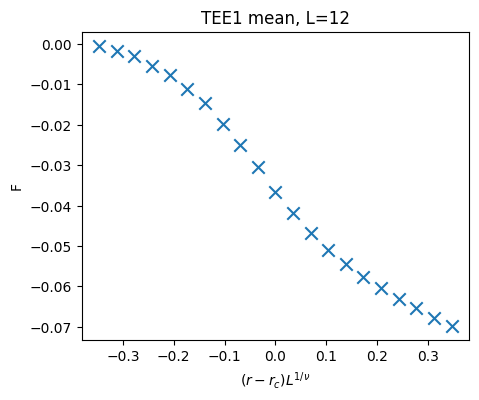

pc = 0.8000 ± nan
nu = 2.0000 ± nan
zeta = 2.0000 ± nan
=== TEE1 variance, L=12 ===


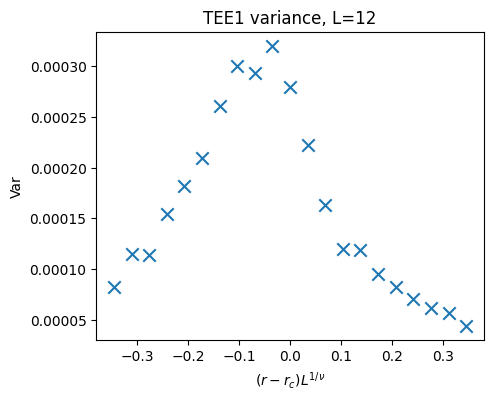

=== TEE2 mean, L=18 ===


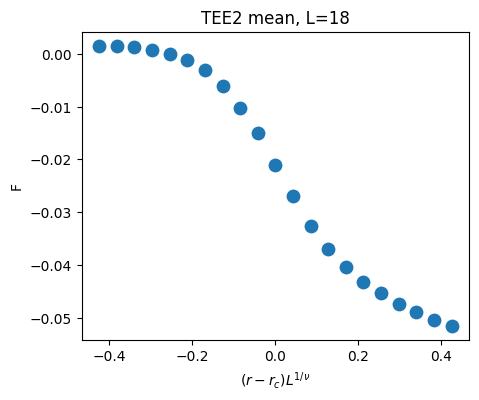

pc = 0.8000 ± nan
nu = 2.0000 ± nan
zeta = 2.0000 ± nan
=== TEE2 variance, L=18 ===


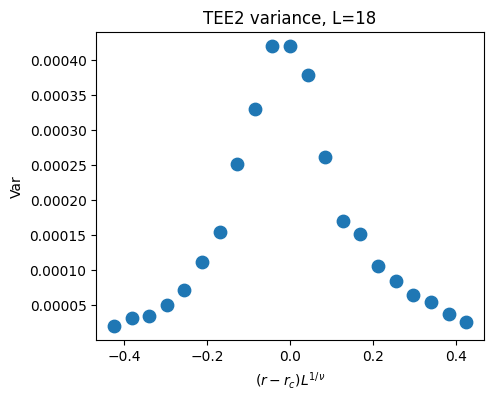

=== TEE3 mean, L=24 ===


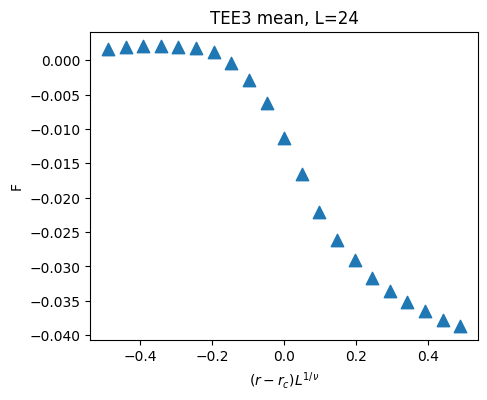

pc = 0.8000 ± nan
nu = 2.0000 ± nan
zeta = 2.0000 ± nan
=== TEE3 variance, L=24 ===


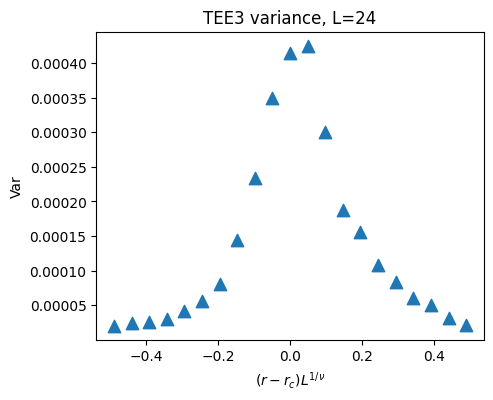

=== TEE4 mean, L=30 ===


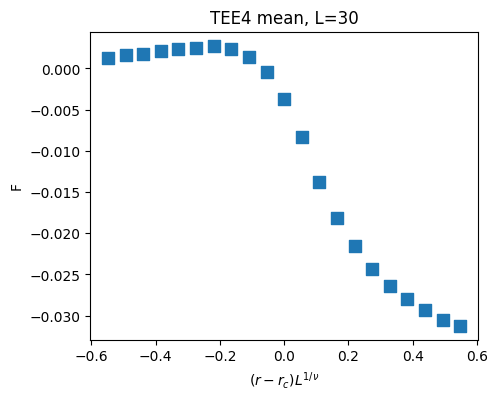

pc = 0.8000 ± nan
nu = 2.0000 ± nan
zeta = 2.0000 ± nan
=== TEE4 variance, L=30 ===


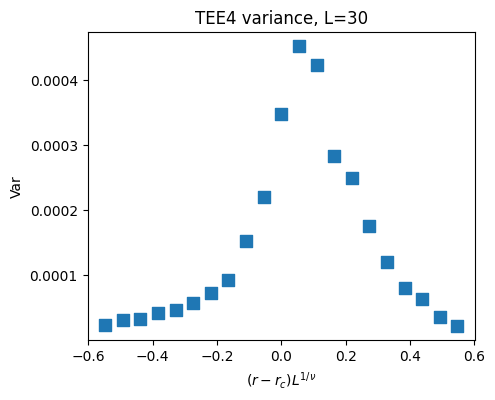

In [14]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
cmap = cm.get_cmap('gnuplot')

# LをTEEごとに指定
L_list = [12, 18, 24, 30]  # TEE1,2,3,4
num_L = 1  # 各TEEは1つのL

# npzデータ
data = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

for tee_idx, L_use in enumerate(L_list, start=1):
    # 平均値
    a_mean  = np.array(data[f'TEE{tee_idx}_ave'], dtype=float).reshape(1,-1)
    da_mean = np.array(data[f'TEE{tee_idx}_err'], dtype=float).reshape(1,-1) * gamma

    # 分散
    a_var  = np.array(data[f'TEE{tee_idx}_var'], dtype=float).reshape(1,-1)
    da_var = np.array(data[f'TEE{tee_idx}_err'], dtype=float).reshape(1,-1) * gamma

    # 平均値 FSS
    print(f"=== TEE{tee_idx} mean, L={L_use} ===")
    ret = fssa.autoscale([L_use], p_use, a_mean, da_mean,
                          rho_c0=0.8, nu0=2, zeta0=2)
    xs, ys, dys = fssa.scaledata([L_use], p_use, a_mean, da_mean, ret.rho, ret.nu, ret.zeta)

    plt.figure(figsize=(5,4))
    plt.scatter(xs.T[:,0], ys.T[:,0], marker=markers[tee_idx-1], s=80)
    plt.xlabel(r'$(r-r_c)L^{1/\nu}$')
    plt.ylabel('F')
    plt.title(f'TEE{tee_idx} mean, L={L_use}')
    plt.show()

    print(f"pc = {ret.rho:.4f} ± {ret.drho:.4f}")
    print(f"nu = {ret.nu:.4f} ± {ret.dnu:.4f}")
    print(f"zeta = {ret.zeta:.4f} ± {ret.dzeta:.4f}")

    # 分散 FSS
    print(f"=== TEE{tee_idx} variance, L={L_use} ===")
    ret = fssa.autoscale([L_use], p_use, a_var, da_var,
                          rho_c0=0.8, nu0=2, zeta0=2)
    xs, ys, dys = fssa.scaledata([L_use], p_use, a_var, da_var, ret.rho, ret.nu, ret.zeta)

    plt.figure(figsize=(5,4))
    plt.scatter(xs.T[:,0], ys.T[:,0], marker=markers[tee_idx-1], s=80)
    plt.xlabel(r'$(r-r_c)L^{1/\nu}$')
    plt.ylabel('Var')
    plt.title(f'TEE{tee_idx} variance, L={L_use}')
    plt.show()


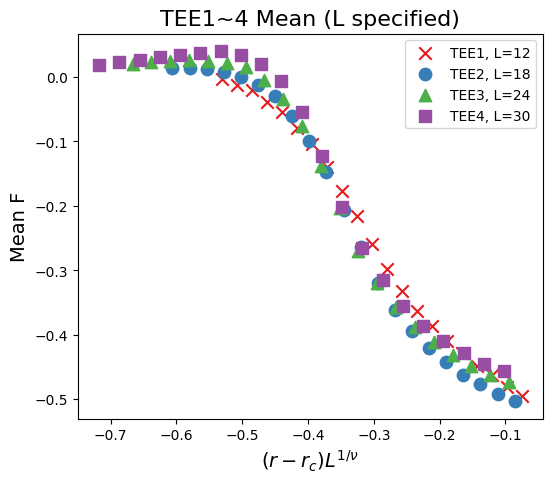

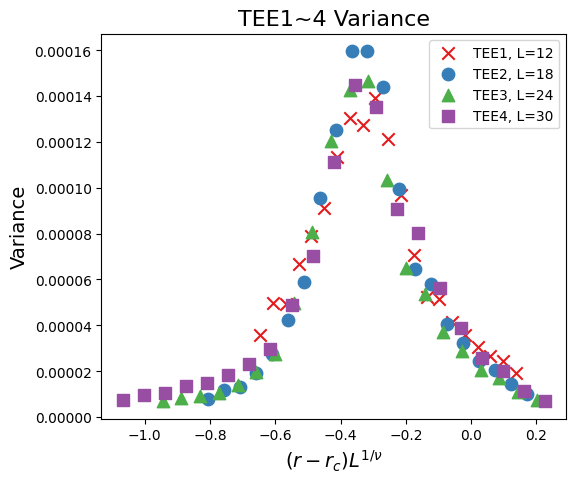

=== 平均 FSS ===
pc = 0.9330324764720757 ± nan
nu = 3.0242828369101638 ± nan
zeta = 0.6393085377263765 ± nan
S = 1199.3133290190847

=== 分散 FSS ===
pc = 0.864929995462808 ± 0.028565609007804114
nu = 1.8210583913889318 ± 0.4657670714501436
zeta = 2.431579125052213 ± 0.6104397672260281
S = 0.1169689689180052


In [14]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [12, 18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


In [27]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


ValueError: a should have shape (l.size, rho.size)

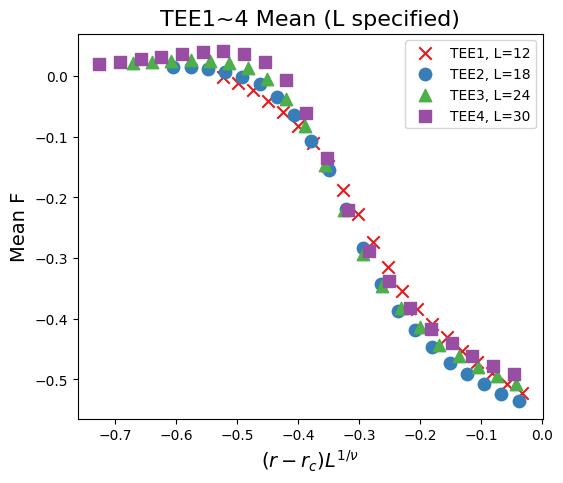

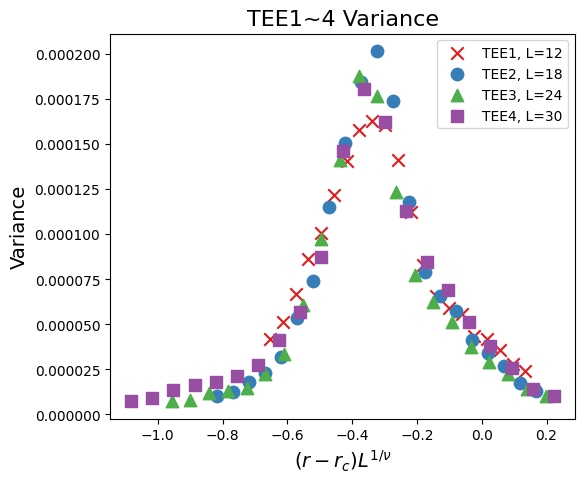

=== 平均 FSS ===
pc = 0.9136781417558111 ± 0.008503355355629677
nu = 2.779909285522029 ± 0.23186782862138694
zeta = 0.5277260952811538 ± 0.2673453863438834
S = 932.0812945343457

=== 分散 FSS ===
pc = 0.8658706865758572 ± 0.016774560613489933
nu = 1.8136784464527294 ± nan
zeta = 2.422311580631736 ± 0.33756374802032435
S = 0.13407554891218854


In [2]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [12, 18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_22_Nd_500_NT_14520_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


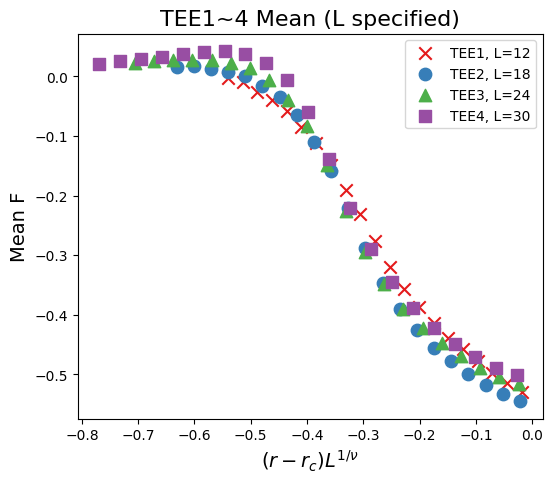

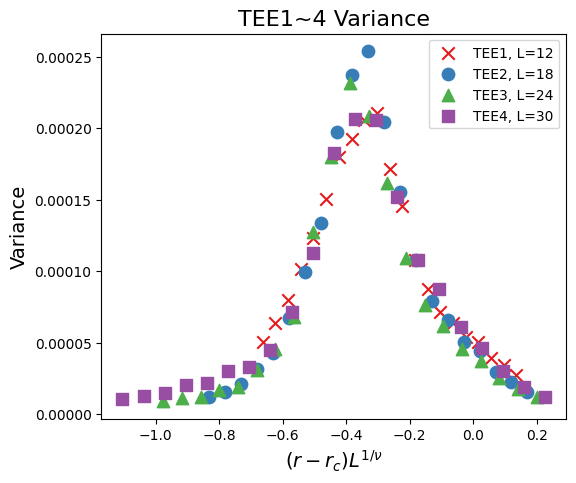

=== 平均 FSS ===
pc = 0.9071631867855829 ± 0.006056279750445226
nu = 2.591947270086914 ± 0.29846736896257803
zeta = 0.47752655831870006 ± 0.2507502186321743
S = 1547.8102005052992

=== 分散 FSS ===
pc = 0.8659994633749868 ± 0.025706348368140525
nu = 1.7942899926062688 ± 0.599938336155639
zeta = 2.37508150118033 ± 0.7150109348226135
S = 0.2884011404389501


In [3]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [12, 18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_20_Nd_1000_NT_12000_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


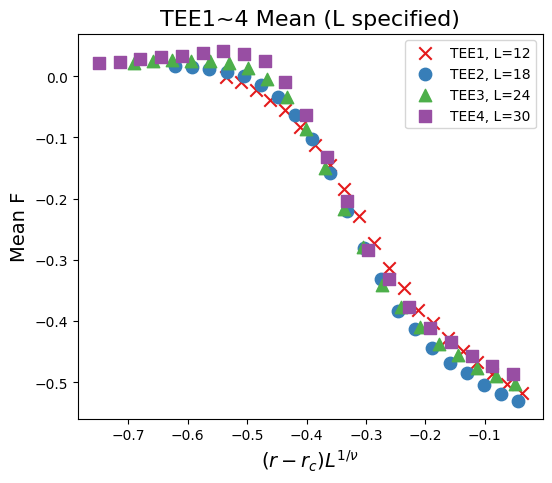

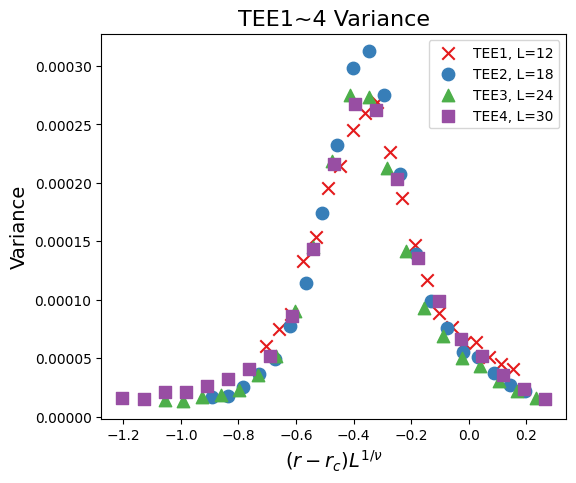

=== 平均 FSS ===
pc = 0.9150037575757983 ± nan
nu = 2.7234216890625413 ± 5.9186436137543055
zeta = 0.5259606237531501 ± 0.9399833581086071
S = 977.843630839883

=== 分散 FSS ===
pc = 0.8638126643984104 ± 0.008304982624472745
nu = 1.7057871007396264 ± nan
zeta = 2.3956733709098863 ± nan
S = 0.40325943739507364


In [31]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

gamma = 0.5
markers = ['x', 'o', '^', 's']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

# TEEと対応するL
L_list = [12, 18, 24, 30]
TEE_keys = ['TEE1', 'TEE2', 'TEE3', 'TEE4']

#L_list = [18, 24, 30]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4']

# データ読み込み
data = np.load("Lx_16_Nd_1000_NT_7680_px_0.0_MPI_hexagonal1234.npz")
p_use = data['pg']

# ----------------------
# 平均 FSS
# ----------------------
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma

ret_mean = fssa.autoscale(L_list, p_use, a_mean, da_mean, rho_c0=0.8, nu0=2, zeta0=2)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean, da_mean,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 分散 FSS （誤差は ave の err を流用）
# ----------------------
a_var = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 暫定流用

ret_var = fssa.autoscale(L_list, p_use, a_var, da_var, rho_c0=0.8, nu0=2, zeta0=2)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var, da_var,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_mean.T[:,i], ys_mean.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean F', fontsize=14)
ax.legend()
plt.title('TEE1~4 Mean (L specified)', fontsize=16)
plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.scatter(xs_var.T[:,i], ys_var.T[:,i],
               marker=markers[i], color=colors[i],
               label=f'TEE{i+1}, L={L}', s=80)
ax.set_xlabel(r'$(r-r_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title('TEE1~4 Variance', fontsize=16)
plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ----------------------
# FSS 結果出力
# ----------------------
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu, "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu, "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S =", fssa.quality(xs_var, ys_var, dys_var))


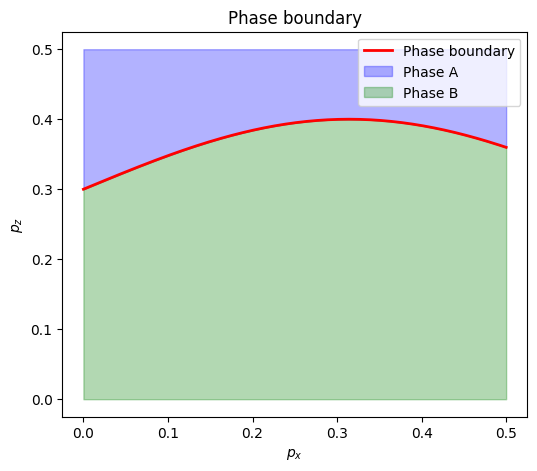

In [23]:
px = np.linspace(0, 0.5, 200)
boundary = 0.3 + 0.1*np.sin(5*px)  # 仮の境界関数

plt.figure(figsize=(6,5))
plt.plot(px, boundary, 'r-', lw=2, label="Phase boundary")
plt.fill_between(px, boundary, 0.5, color="blue", alpha=0.3, label="Phase A")
plt.fill_between(px, 0, boundary, color="green", alpha=0.3, label="Phase B")
plt.xlabel(r"$p_x$")
plt.ylabel(r"$p_z$")
plt.title("Phase boundary")
plt.legend()
plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ==== サンプルデータ (離散的な臨界点) ====
# 例えば (pg, px) パラメータで臨界点 pc を測定した場合
pg = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
px = np.array([0.05, 0.1, 0.15, 0.2, 0.25])
pc  = np.array([0.7, 0.72, 0.75, 0.78, 0.8])  # 臨界点 (例)

# ==== グリッドを作成して補間 ====
PG, PX = np.meshgrid(np.linspace(0, 0.5, 100),
                     np.linspace(0, 0.3, 100))

PC_grid = griddata((pg, px), pc, (PG, PX), method='cubic')

# ==== 図を描画 ====
plt.figure(figsize=(6, 5))

# 相図をカラーマップで表示
c = plt.contourf(PG, PX, PC_grid, levels=20, cmap="viridis")

# カラーバー
plt.colorbar(c, label="Critical point $p_c$")

# 元データ点をプロット
plt.scatter(pg, px, c='red', edgecolors='black', s=60, label="data")

# 装飾
plt.xlabel("$p_g$")
plt.ylabel("$p_x$")
plt.legend()
plt.title("Phase diagram (interpolated)")
plt.show()


QhullError: QH6154 Qhull precision error: Initial simplex is flat (facet 1 is coplanar with the interior point)

While executing:  | qhull d Qt Qc Qbb Qz Q12
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 921928627  delaunay  Qtriangulate  Qcoplanar-keep  Qbbound-last
  Qz-infinity-point  Q12-allow-wide  _pre-merge  _zero-centrum  Qinterior-keep
  Pgood  _max-width 0.4  Error-roundoff 6.9e-16  _one-merge 4.9e-15
  Visible-distance 1.4e-15  U-max-coplanar 1.4e-15  Width-outside 2.8e-15
  _wide-facet 8.3e-15  _maxoutside 5.5e-15

The input to qhull appears to be less than 3 dimensional, or a
computation has overflowed.

Qhull could not construct a clearly convex simplex from points:
- p3(v4):   0.4   0.2  0.28
- p5(v3):   0.3  0.15   0.5
- p4(v2):   0.5  0.25  0.45
- p0(v1):   0.1  0.05     0

The center point is coplanar with a facet, or a vertex is coplanar
with a neighboring facet.  The maximum round off error for
computing distances is 6.9e-16.  The center point, facets and